### 🤖 Modelo de Risco de Defasagem

**Base:** `df_ml_pares.parquet` — gerado no `12_Feature_Engineering.ipynb`

**Objetivo:** Construir modelo preditivo que estime a probabilidade de um aluno entrar em defasagem (IAN < 10) no ano seguinte.

**Modelo:** HistGradientBoostingClassifier (melhor AUC nos testes anteriores: 0.8482)

**Validação:** Temporal 
- treino com pares 2022->2023
- teste com pares 2023->2024

In [57]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay)

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

VERSAO = 'v4'
df_pares = pd.read_parquet(f'../../../data/db/01_silver_processed/df_ml_pares_{VERSAO}.parquet')
features = json.loads(df_pares['features'].iloc[0])

print(f'Dataset: {df_pares.shape[0]} pares | {df_pares.shape[1]} colunas')
print(f'Features: {features}')
print(f'Colunas: {df_pares.columns.tolist()}')

Dataset: 1369 pares | 34 colunas
Features: ['IDA_norm', 'IEG_norm', 'IPS_norm', 'IPP_norm', 'IPV_norm', 'IAN', 'resiliencia', 'nivel_num', 'tipo_escola']
Colunas: ['RA', 'ano_atual', 'ano_proximo', 'target', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'nivel', 'pedra', 'instituicao', 'ano_ingresso', 'gap_iaa_ida', 'resiliencia', 'primeiro_ano', 'tipo_escola', 'ips_no_piso', 'IDA_norm', 'IEG_norm', 'IAA_norm', 'IPS_norm', 'IPP_norm', 'IPV_norm', 'nivel_num', 'pedra_num', 'risco_defasagem', 'risco_ida_baixo', 'risco_superestima', 'risco_ieg_baixo', 'score_risco', 'features']


### Preparação dos dados

In [58]:
# Separação temporal
df_treino = df_pares[df_pares['ano_atual'] == 2022].copy()
df_teste = df_pares[df_pares['ano_atual'] == 2023].copy()

X_treino = df_treino[features]
y_treino = df_treino['target']
X_teste = df_teste[features]
y_teste = df_teste['target']

print(f'=== Dados ===')
print(f'|_  Treino: {X_treino.shape[0]} amostras, target={y_treino.mean()*100:.1f}% defasados')
print(f'|_  Teste:  {X_teste.shape[0]} amostras, target={y_teste.mean()*100:.1f}% defasados')
print(f'|_  Features: {len(features)}')

=== Dados ===
|_  Treino: 604 amostras, target=60.8% defasados
|_  Teste:  765 amostras, target=40.3% defasados
|_  Features: 9


### Tuning de hiperparâmetros

In [59]:
# Busca dos melhores hiperparâmetros via cross-validation
param_grid = {
    'max_iter': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30],
    'l2_regularization': [0, 0.1, 1.0],
}

RANDOM_STATE = 157

grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid, scoring='roc_auc', cv=5, n_jobs=-1, verbose=1
)
grid.fit(X_treino, y_treino)

print(f'\n=== Melhor combinação ===')
print(f'  Parâmetros: {grid.best_params_}')
print(f'  AUC (CV treino): {grid.best_score_:.4f}')

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

=== Melhor combinação ===
  Parâmetros: {'l2_regularization': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'max_iter': 100, 'min_samples_leaf': 10}
  AUC (CV treino): 0.7647


In [60]:
# Tuning mais focado ao redor dos parâmetros que já funcionavam
param_grid = {
    'max_iter': [150, 200, 250, 300],
    'max_depth': [5, 6, 7, 8],
    'learning_rate': [0.05, 0.1, 0.15],
    'min_samples_leaf': [5, 10, 15, 20],
    'l2_regularization': [0, 0.01, 0.1],
}

RANDOM_STATE = 157

grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid, scoring='roc_auc', cv=5, n_jobs=-1, verbose=1
)
grid.fit(X_treino, y_treino)

print(f'\n=== Melhor combinação ===')
print(f'  Parâmetros: {grid.best_params_}')
print(f'  AUC (CV treino): {grid.best_score_:.4f}')

Fitting 5 folds for each of 576 candidates, totalling 2880 fits

=== Melhor combinação ===
  Parâmetros: {'l2_regularization': 0.1, 'learning_rate': 0.05, 'max_depth': 8, 'max_iter': 150, 'min_samples_leaf': 10}
  AUC (CV treino): 0.6432


### Avaliação dos melhores hiperparâmetros

=== AUC no teste: 0.8457 ===

=== Classification Report (threshold=0.5) ===
              precision    recall  f1-score   support

    Adequado       0.85      0.63      0.73       457
    Defasado       0.60      0.83      0.70       308

    accuracy                           0.71       765
   macro avg       0.73      0.73      0.71       765
weighted avg       0.75      0.71      0.72       765



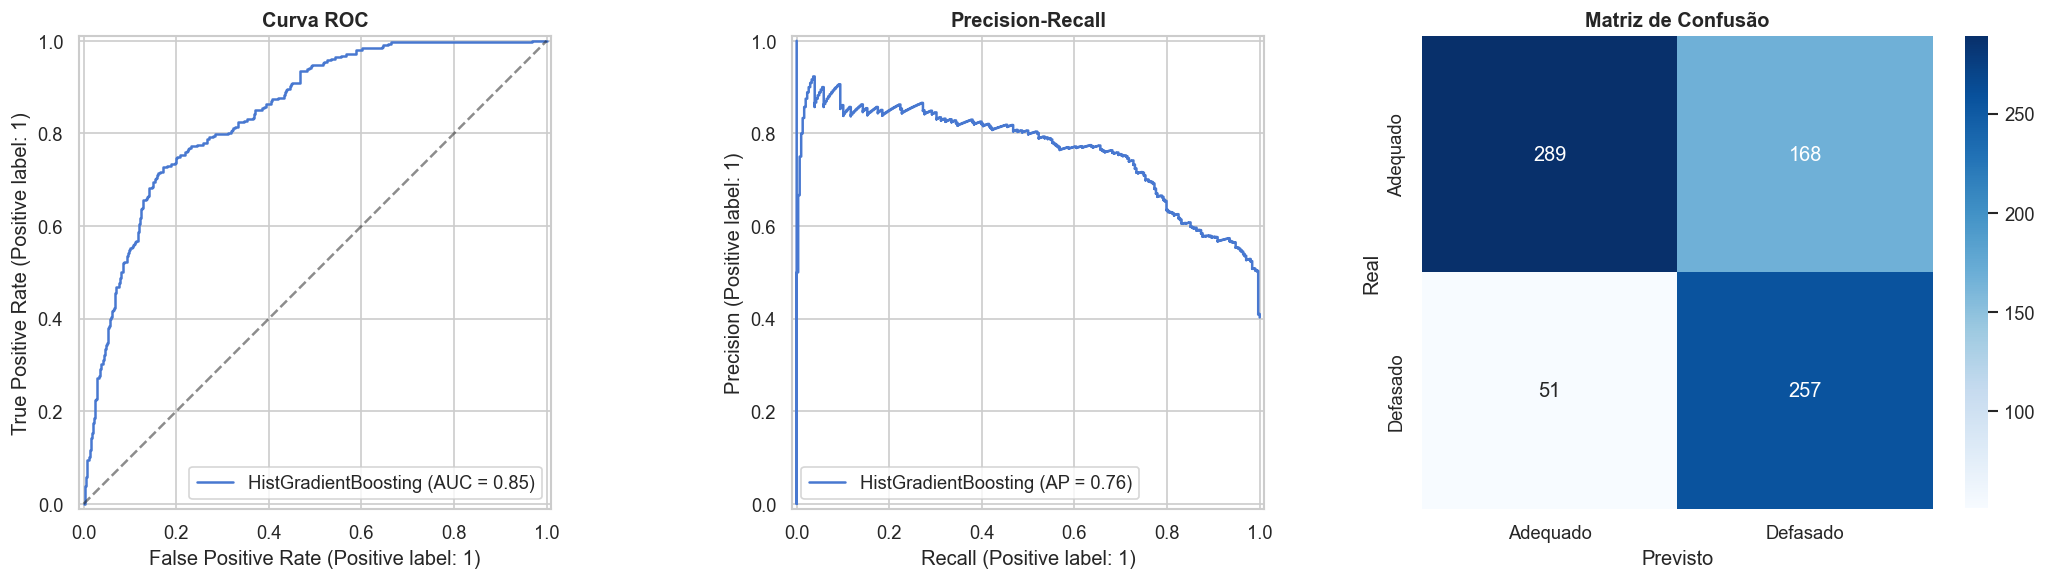

In [61]:
# Avaliar no teste com os melhores hiperparâmetros
modelo = grid.best_estimator_

y_prob = modelo.predict_proba(X_teste)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_teste, y_prob)
print(f'=== AUC no teste: {auc:.4f} ===')
print(f'\n=== Classification Report (threshold=0.5) ===')
print(classification_report(y_teste, y_pred, target_names=['Adequado', 'Defasado']))

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_teste, y_prob, ax=axes[0], name='HistGradientBoosting')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('Curva ROC', fontweight='bold')

# Precision-Recall
PrecisionRecallDisplay.from_predictions(y_teste, y_prob, ax=axes[1], name='HistGradientBoosting')
axes[1].set_title('Precision-Recall', fontweight='bold')

# Matriz de confusão
cm = confusion_matrix(y_teste, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Adequado', 'Defasado'], yticklabels=['Adequado', 'Defasado'])
axes[2].set_title('Matriz de Confusão', fontweight='bold')
axes[2].set_xlabel('Previsto')
axes[2].set_ylabel('Real')

plt.tight_layout()
plt.show()

### Feature Importance

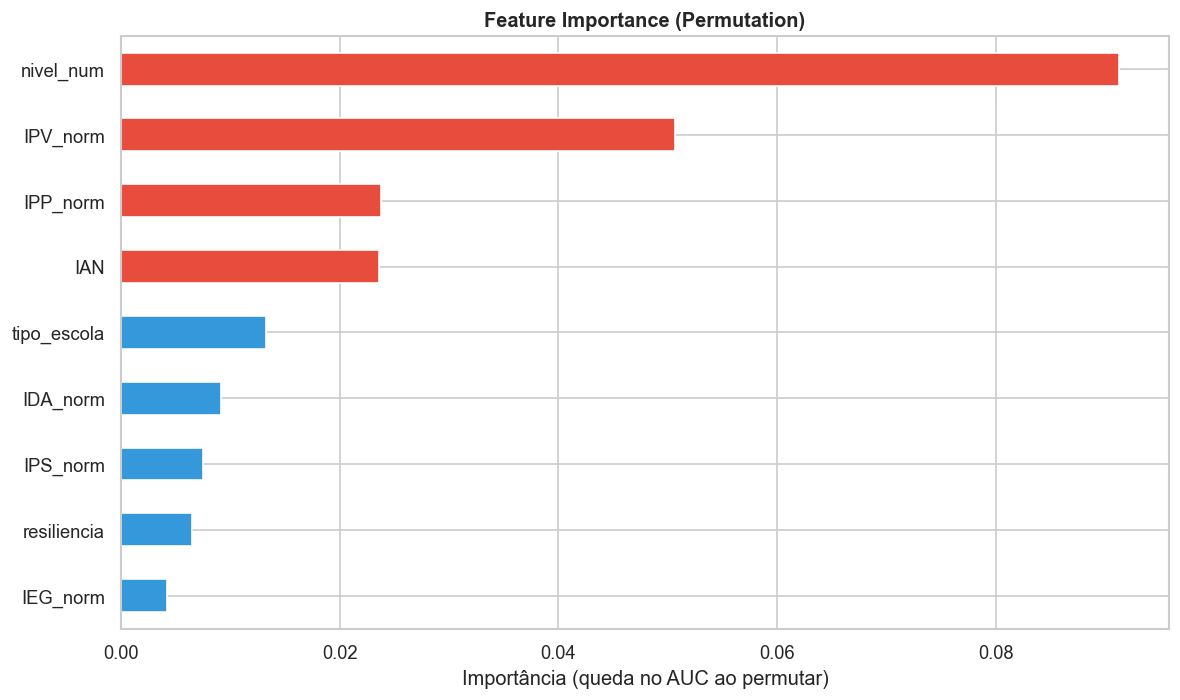

=== Ranking de features ===
  nivel_num           : 0.0913
  IPV_norm            : 0.0507
  IPP_norm            : 0.0238
  IAN                 : 0.0236
  tipo_escola         : 0.0132
  IDA_norm            : 0.0092
  IPS_norm            : 0.0075
  resiliencia         : 0.0065
  IEG_norm            : 0.0042


In [62]:
# Feature importance via permutation
result = permutation_importance(modelo, X_teste, y_teste, 
                                 n_repeats=10, random_state=42, scoring='roc_auc')

feat_imp = pd.Series(result.importances_mean, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', ax=ax, 
              color=['#e74c3c' if v > feat_imp.median() else '#3498db' for v in feat_imp.values])
ax.set_title('Feature Importance (Permutation)', fontweight='bold')
ax.set_xlabel('Importância (queda no AUC ao permutar)')
plt.tight_layout()
plt.show()

print('=== Ranking de features ===')
for feat, imp in feat_imp.sort_values(ascending=False).items():
    print(f'  {feat:20}: {imp:.4f}')

### Análise de probabilidades

=== Faixas de risco ===
               n  pct_defasado
faixa_risco                   
Muito baixo  235           6.4
Baixo         61          26.2
Moderado      66          30.3
Alto          85          37.6
Muito alto   318          70.8


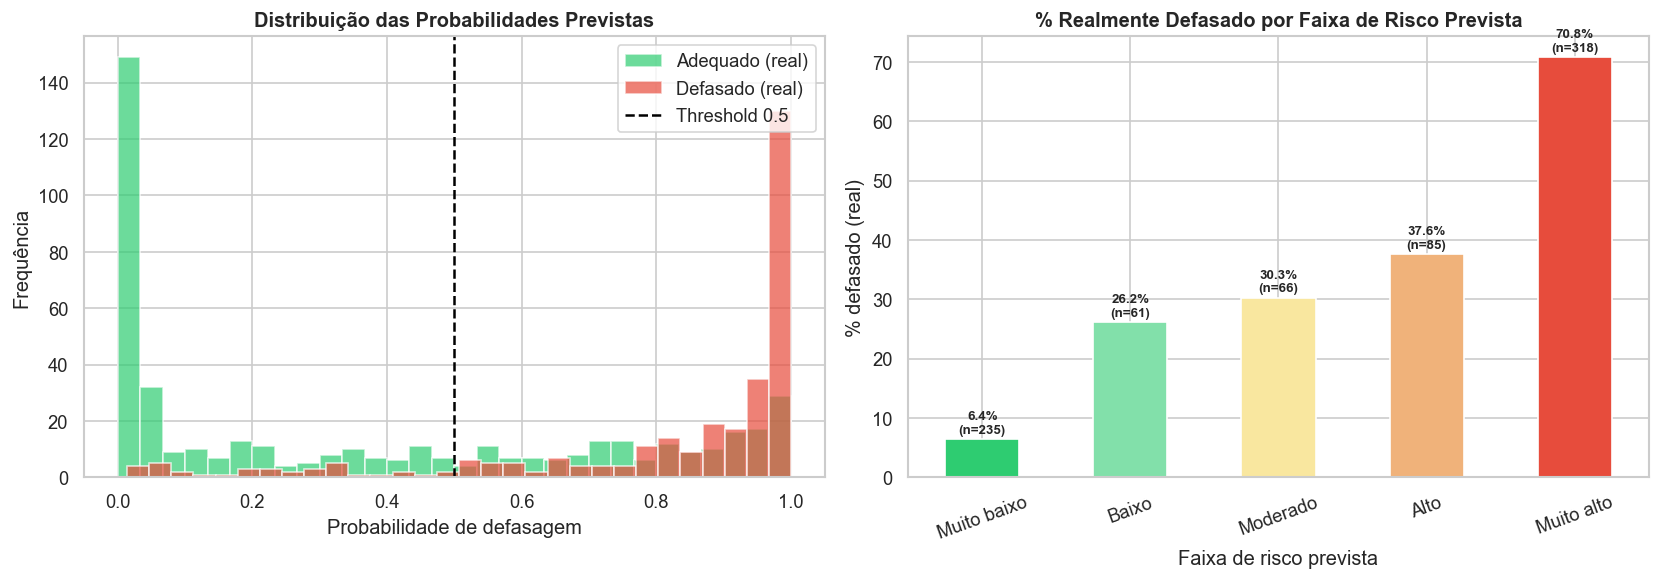

In [63]:
# Distribuição das probabilidades previstas
df_teste_result = df_teste[['RA', 'ano_atual', 'target']].copy()
df_teste_result['prob_defasagem'] = y_prob_melhor

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma das probabilidades
axes[0].hist(df_teste_result[df_teste_result['target'] == 0]['prob_defasagem'],
             bins=30, alpha=0.7, label='Adequado (real)', color='#2ecc71')
axes[0].hist(df_teste_result[df_teste_result['target'] == 1]['prob_defasagem'],
             bins=30, alpha=0.7, label='Defasado (real)', color='#e74c3c')
axes[0].axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
axes[0].set_title('Distribuição das Probabilidades Previstas', fontweight='bold')
axes[0].set_xlabel('Probabilidade de defasagem')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Faixas de risco
df_teste_result['faixa_risco'] = pd.cut(df_teste_result['prob_defasagem'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Muito baixo', 'Baixo', 'Moderado', 'Alto', 'Muito alto'])

faixa_stats = df_teste_result.groupby('faixa_risco').agg(
    n=('target', 'count'),
    pct_defasado=('target', 'mean')
).round(3)
faixa_stats['pct_defasado'] = (faixa_stats['pct_defasado'] * 100).round(1)

print('=== Faixas de risco ===')
print(faixa_stats.to_string())

cores_faixa = ['#2ecc71', '#82e0aa', '#f9e79f', '#f0b27a', '#e74c3c']
faixa_stats['pct_defasado'].plot(kind='bar', ax=axes[1], color=cores_faixa)
axes[1].set_title('% Realmente Defasado por Faixa de Risco Prevista', fontweight='bold')
axes[1].set_ylabel('% defasado (real)')
axes[1].set_xlabel('Faixa de risco prevista')
axes[1].tick_params(axis='x', rotation=20)

for i, (faixa, row) in enumerate(faixa_stats.iterrows()):
    axes[1].text(i, row['pct_defasado'] + 1, f'{row["pct_defasado"]:.1f}%\n(n={int(row["n"])})',
                 ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

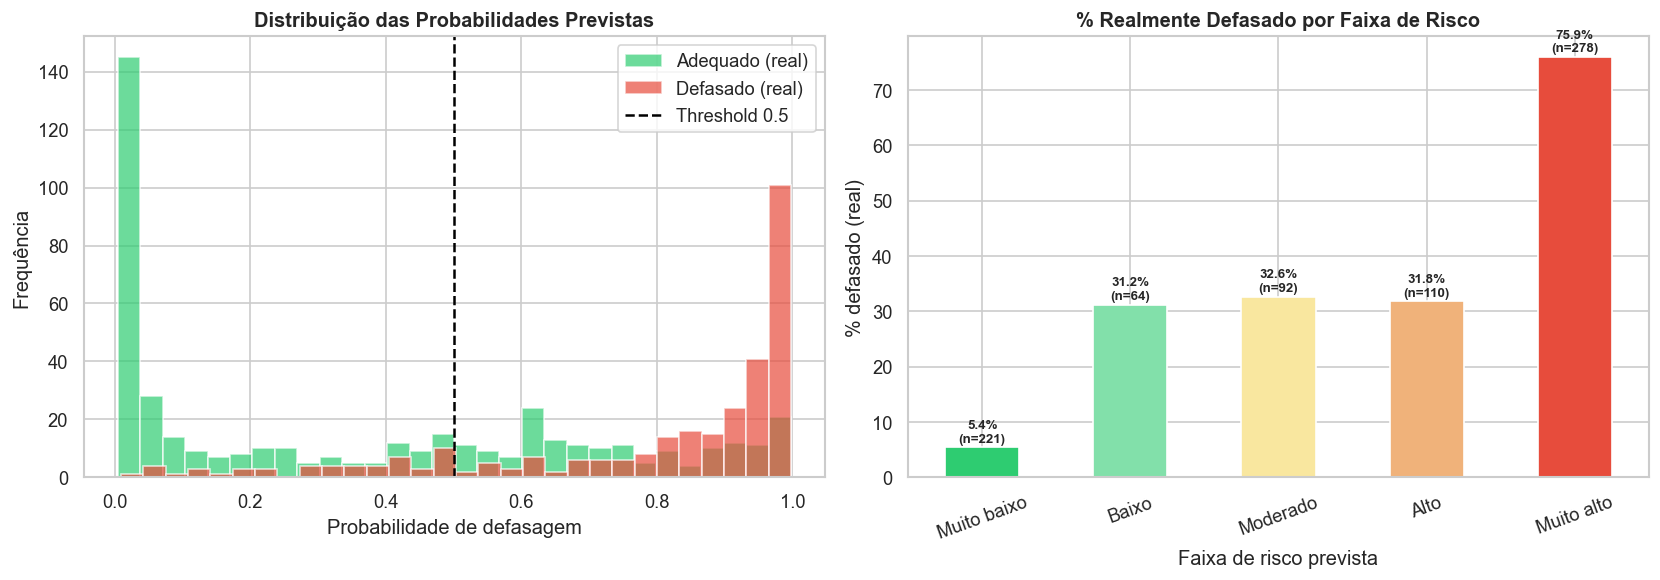

=== Faixas de risco ===
               n  pct_defasado
faixa_risco                   
Muito baixo  221           5.4
Baixo         64          31.2
Moderado      92          32.6
Alto         110          31.8
Muito alto   278          75.9


In [64]:
# Distribuição das probabilidades e faixas de risco
df_resultado = df_teste[['RA', 'ano_atual', 'target']].copy()
df_resultado['prob_defasagem'] = y_prob

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_resultado[df_resultado['target'] == 0]['prob_defasagem'],
             bins=30, alpha=0.7, label='Adequado (real)', color='#2ecc71')
axes[0].hist(df_resultado[df_resultado['target'] == 1]['prob_defasagem'],
             bins=30, alpha=0.7, label='Defasado (real)', color='#e74c3c')
axes[0].axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
axes[0].set_title('Distribuição das Probabilidades Previstas', fontweight='bold')
axes[0].set_xlabel('Probabilidade de defasagem')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Faixas de risco
df_resultado['faixa_risco'] = pd.cut(df_resultado['prob_defasagem'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Muito baixo', 'Baixo', 'Moderado', 'Alto', 'Muito alto'])

faixa_stats = df_resultado.groupby('faixa_risco').agg(
    n=('target', 'count'),
    pct_defasado=('target', 'mean')
).round(3)
faixa_stats['pct_defasado'] = (faixa_stats['pct_defasado'] * 100).round(1)

cores_faixa = ['#2ecc71', '#82e0aa', '#f9e79f', '#f0b27a', '#e74c3c']
faixa_stats['pct_defasado'].plot(kind='bar', ax=axes[1], color=cores_faixa)
axes[1].set_title('% Realmente Defasado por Faixa de Risco', fontweight='bold')
axes[1].set_ylabel('% defasado (real)')
axes[1].set_xlabel('Faixa de risco prevista')
axes[1].tick_params(axis='x', rotation=20)

for i, (faixa, row) in enumerate(faixa_stats.iterrows()):
    axes[1].text(i, row['pct_defasado'] + 1, f'{row["pct_defasado"]:.1f}%\n(n={int(row["n"])})',
                 ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print('=== Faixas de risco ===')
print(faixa_stats.to_string())

### 💡 Insights

